# Risco de crédito: estudo reproduzível
Execute todas as células em ordem. O processamento parte dos CSVs originais, verifica sua integridade e regenera as análises. O alvo positivo é inadimplência.

In [1]:
from pathlib import Path
import sys, os, runpy
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'credit_risk_dataset.csv').exists(), 'Abra o notebook na pasta do projeto.'
sys.path.insert(0, str(ROOT / 'notebooks'))
os.environ.setdefault('MPLCONFIGDIR', '/tmp/credito-matplotlib')


'/private/tmp/credito-matplotlib'

## Execução completa
O processamento dos scripts é executado aqui. Imputação, codificação, balanceamento e escala são ajustados dentro de cada dobra. Os parâmetros são registrados antes das predições de teste.

In [2]:
runpy.run_path(str(ROOT / 'notebooks/09_validacao_corrigida.py'), run_name='__main__')


EDA gerada; integridade dos CSVs confirmada.


Validação: dobra 1/5 concluída.


Validação: dobra 2/5 concluída.


Validação: dobra 3/5 concluída.


Validação: dobra 4/5 concluída.


Validação: dobra 5/5 concluída.


Pipeline concluído; oito configurações e integridade verificadas.


{'__name__': '__main__',
 '__doc__': 'Entrada principal: EDA, preparação, experimentos e avaliação reproduzíveis.',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/elydocarmobarros/Desktop/ESTUDOS TEC/projeto/SEMANAL/semana 13/projeto/notebooks/09_validacao_corrigida.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built

## 1. EDA

# EDA: gráficos e interpretação

## Distribuição do alvo

A inadimplência representa 21.82% dos registros. Há diferença relevante entre as classes; o split deverá preservar a proporção e a avaliação usará recall, precisão e F1 além da acurácia. O balanceamento, quando aplicado, ficará restrito ao treino.

## Renda anual

A mediana da renda é 60,000 para contratos em dia e 41,498 para contratos inadimplentes. O histograma usa intervalos comuns e eixo logarítmico, sem remover registros. Cada classe é normalizada separadamente; a altura mostra sua fração no intervalo. Valores altos não demonstram erro por si sós.

## Comprometimento da renda

As medianas de `loan_percent_income` são 0.130 para a classe 0 e 0.240 para a classe 1. A correlação de Pearson com o alvo é 0.379; isso é associação descritiva, não causalidade.

## Correlações e próximos passos

A correlação entre `loan_status` e `loan_int_rate` é 0.335. Correlação não determina exclusão automática nem causalidade. A preparação remove repetições exatas e idades de 123/144 anos e invalida dois tempos de emprego impossíveis. Mantém rendas extremas plausíveis, substitui a razão redundante pela coluna exigida e aprende imputadores somente no treino. Esta EDA descreve toda a base; não é uma análise cega de holdout.

As figuras ficam em `resultados/graficos_eda/`. Os CSVs foram apenas lidos e tiveram seus hashes conferidos antes e depois da execução.


,Unnamed: 0,tipo,nulos
0,person_age,int64,0
1,person_income,int64,0
2,person_home_ownership,str,0
3,person_emp_length,float64,895
4,loan_intent,str,0
5,loan_grade,str,0
6,loan_amnt,int64,0
7,loan_int_rate,float64,3116
8,loan_status,int64,0
9,loan_percent_income,float64,0


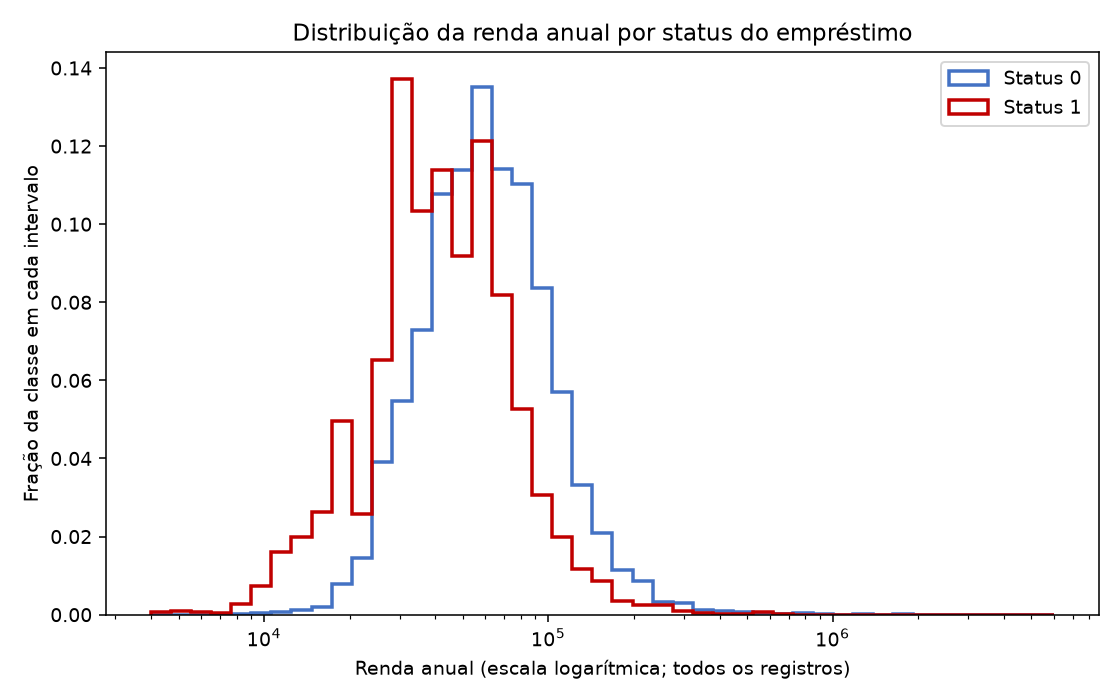

In [3]:
display(Markdown((ROOT / 'documentacao/eda_graficos.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/graficos_eda/inventario.csv'))
display(Image(filename=str(ROOT / 'resultados/graficos_eda/02_histograma_renda_status.png')))


Dimensões originais: (32581, 12)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


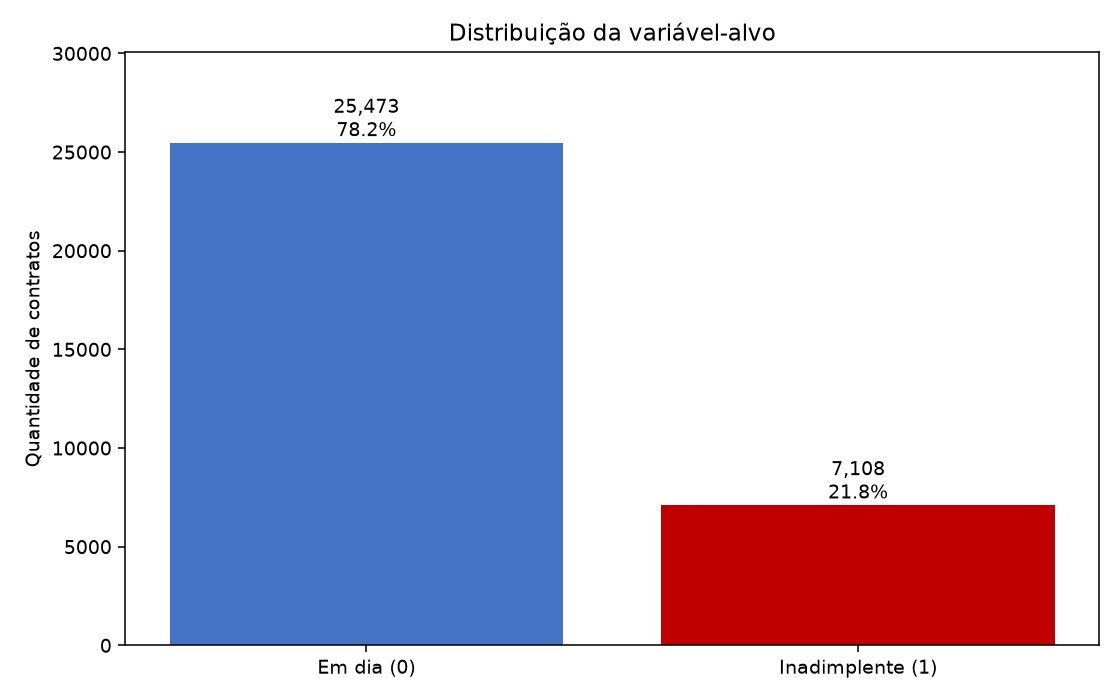

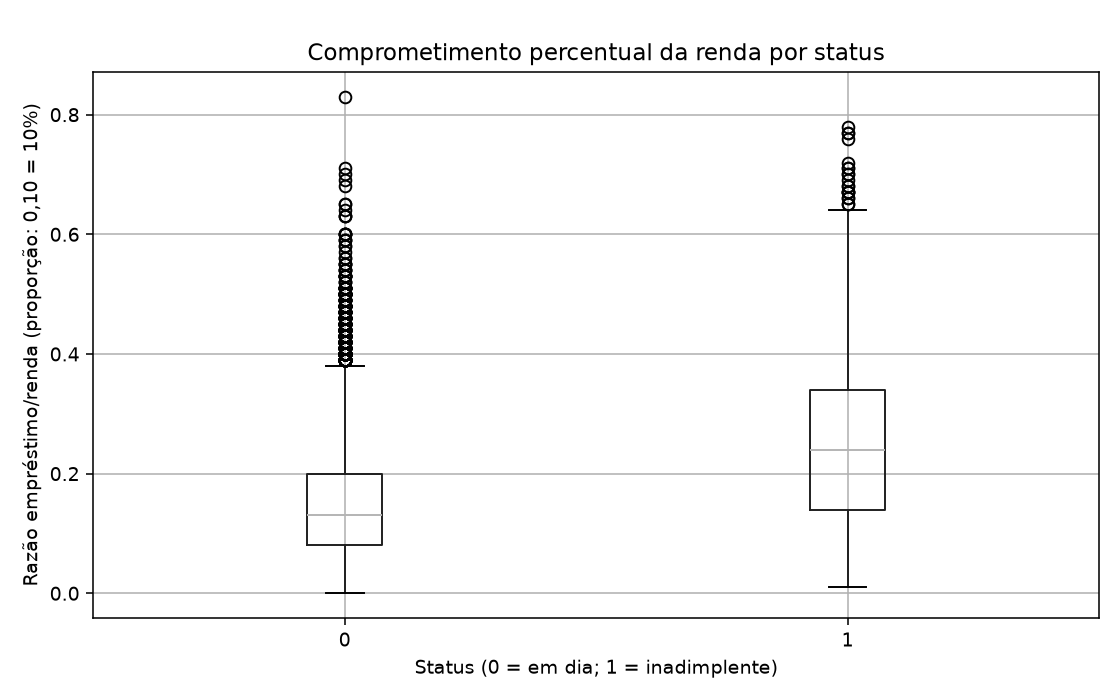

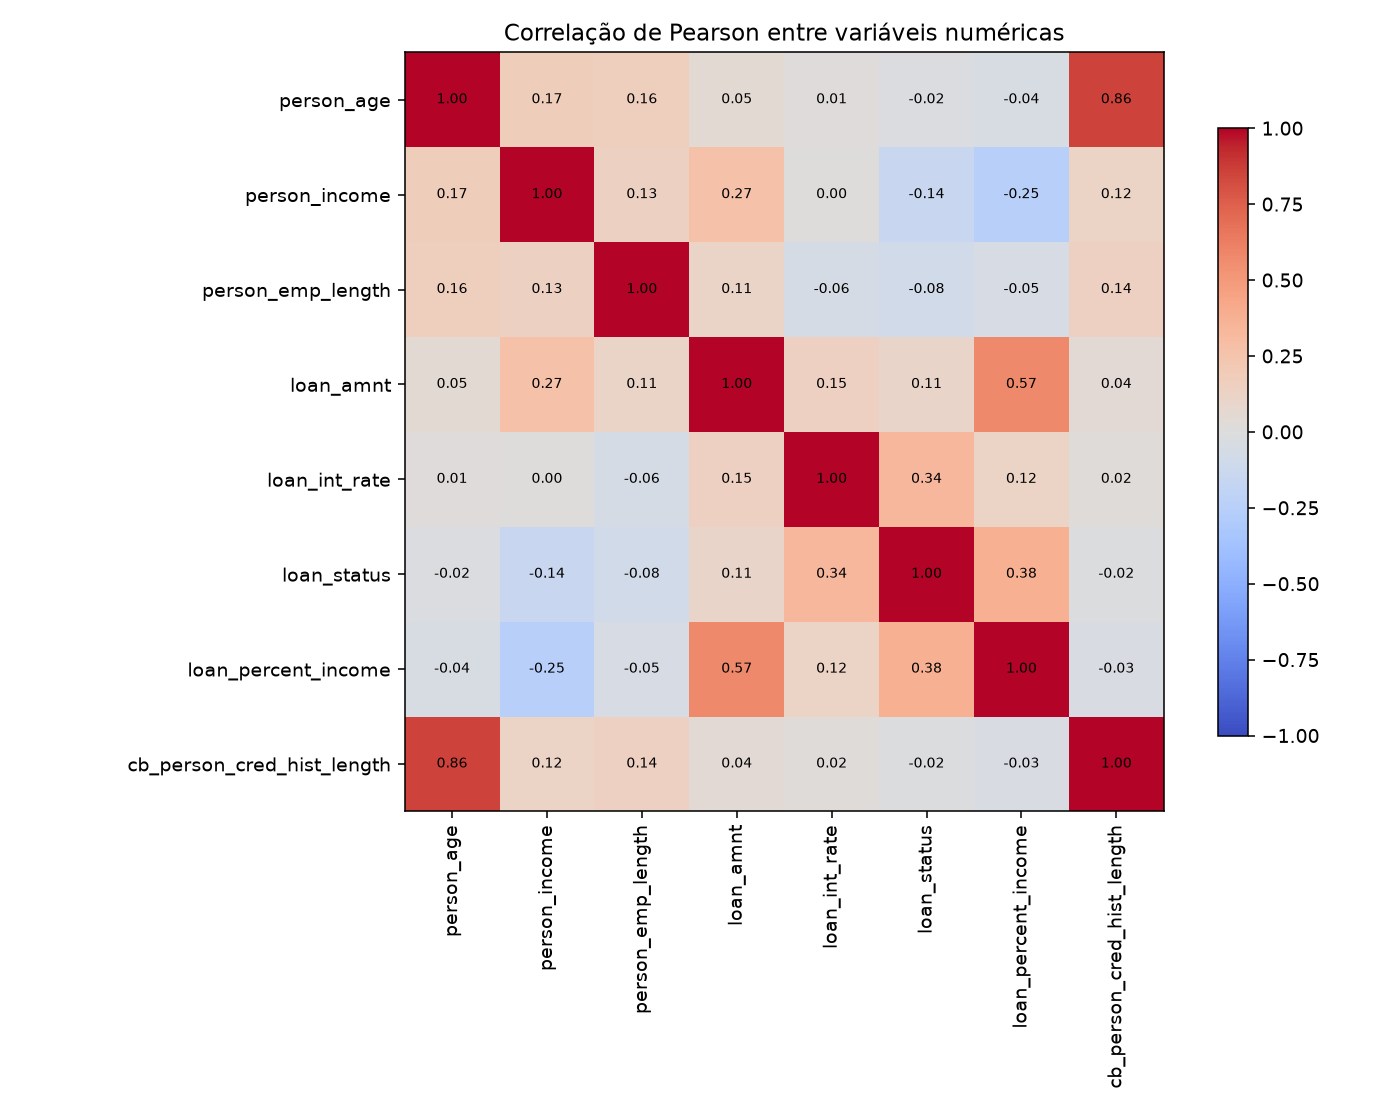

In [4]:
raw = pd.read_csv(ROOT / 'credit_risk_dataset.csv')
print('Dimensões originais:', raw.shape)
display(raw.describe())
for name in ['01_distribuicao_alvo', '03_boxplot_comprometimento', '04_correlacao_pearson']:
    display(Image(filename=str(ROOT / f'resultados/graficos_eda/{name}.png')))


## 2. Tratamento e limpeza

In [5]:
display(Markdown((ROOT / 'documentacao/data_prep.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/estatisticas_treino.csv'))


# Limpeza e imputação

Foram removidas 165 repetições exatas, mantendo a primeira ocorrência.
Sem identificador de cliente, igualdade não prova que sejam a mesma pessoa; a opção segue a exigência
da estudo de remover redundâncias e evita casos idênticos nas duas partições.

A exclusão por idade usa uma regra explícita de plausibilidade para este estudo: idade >=120.
Os registros observados tinham [144, 144, 123, 123, 144]; não há idades entre 101 e 119.
Não afirmamos que toda idade acima de 100 seja impossível. As idades extremas repetidas,
sem possibilidade de confirmar a informação na fonte, foram excluídas desta análise.
A regra é uma decisão de qualidade de dados, não uma política de concessão de crédito.
A lista está em resultados/idades_excluidas.csv.

Dois tempos de emprego de 123 anos em pessoas de 21 e 22 anos foram convertidos em nulos
antes de qualquer separação. As outras colunas dessas linhas foram preservadas.
A base ficou com 32411 linhas.

## Estatísticas somente do treino

| index | mean | median | skew | nulos |
| --- | --- | --- | --- | --- |
| person_emp_length | 4.7784 | 4.0000 | 1.2259 | 717 |
| loan_int_rate | 11.0133 | 10.9900 | 0.2014 | 2482 |

Tempo de emprego: mediana, porque a cauda direita permanece após corrigir os erros;
a mediana é menos influenciada por valores altos. Taxa de juros: média, porque média e
mediana são próximas e a assimetria é pequena. Essas são escolhas prévias à seleção
dos modelos. Cada dobra aprende seus próprios valores; o ajuste final usa todo o treino.
As demais numéricas têm mediana como regra de contingência, mas não apresentam nulos nesta base.

Rendas e empréstimos positivos extremos são mantidos: raridade não demonstra erro.
Valores extremos podem deslocar as distâncias do KNN mesmo após StandardScaler, que não
é um tratamento robusto de outliers. A árvore dispensa escala e é menos sensível à magnitude,
mas ainda pode aprender cortes inadequados com registros errados. Essa limitação é registrada.

Os CSVs originais são verificados por hash. A rastreabilidade é armazenada separadamente
em dados_derivados/origens.csv e nunca entra nos preditores.


,Unnamed: 0,count,mean,median,std,min,max,skew,nulos
0,person_age,25928.0,27.694500,26.000000,6.176875,20.00000,94.00,1.936426,0
1,person_income,25928.0,65748.270441,55000.000000,52144.459305,4000.00000,2039784.00,9.693959,0
2,person_emp_length,25211.0,4.778351,4.000000,4.021952,0.00000,38.00,1.225923,717
3,loan_amnt,25928.0,9575.669161,8000.000000,6305.528961,500.00000,35000.00,1.190090,0
4,loan_int_rate,23446.0,11.013347,10.990000,3.233262,5.42000,23.22,0.201438,2482
5,cb_person_cred_hist_length,25928.0,5.794315,4.000000,4.046429,2.00000,30.00,1.664362,0
6,comprometimento_renda,25928.0,17.057704,14.814815,10.717736,0.21097,83.00,1.065463,0


## 3. Feature engineering

In [6]:
display(Markdown((ROOT / 'documentacao/feature_engineering.md').read_text()))


# Engenharia de atributos

A fórmula definido é (loan_amnt / person_income) * 100. Ela relaciona o valor total
do empréstimo à renda anual informada; não mede parcela mensal nem comprometimento mensal.

Ambos os operandos são verificados quanto a nulos, infinitos e valores não positivos
antes da divisão. O cálculo mascarado não executa divisões inválidas.
Nesta base não há operandos inválidos: 32411 razões finitas e
0 nulos. Se houver operandos inválidos em outra base, a etapa interrompe
em vez de imputar globalmente; eventual imputação deve ocorrer somente no treino.

loan_percent_income está em proporção; comprometimento_renda está em percentual.
A diferença mediana entre as duas, na mesma unidade, é
0.2500 ponto percentual.
98.68% das linhas diferem em até 0,5001 ponto.
A versão original é retirada dos preditores para evitar peso redundante no KNN.
Não se trata de colinearidade estrita comprovada.


## 4. Separação, balanceamento e escalonamento

In [7]:
display(Markdown((ROOT / 'documentacao/separacao_preparacao.md').read_text()))


# Separação e preparação

Split 80/20 com stratify=y e random_state=42: 25928 linhas de treino e
6483 de teste. A identidade é o número da linha no CSV original (base zero).
Os índices e as repetições estão em resultados/indices_split.csv e
resultados/indices_treino_balanceado.csv.

Imputação e One-Hot Encoding são ajustados somente no treino de cada dobra.
A validação recebe apenas transform. O oversampling mantém cada linha de treino
e acrescenta cópias da classe minoritária. O ajuste final tem 40514 linhas
balanceadas, preservando todas as 25928 originais do treino.
As duas famílias recebem exatamente os mesmos índices balanceados.

StandardScaler é ajustado depois do balanceamento. Somente renda, tempo de emprego,
valor do empréstimo, taxa de juros e comprometimento_renda são escalonados.
Idade e duração do histórico, registradas em anos inteiros, são tratadas como discretas
e ficam sem escala; as dummies também não são escalonadas. Essa decisão atende à
separação pedida entre contínuas e demais atributos, mas deixa as durações em sua
unidade original no cálculo de distância. A árvore usa todas as variáveis sem escala.

Nenhum parâmetro estatístico é aprendido no teste. Há auditoria de sobreposição de origem
e de preservação dos registros nas cinco dobras e no ajuste final.

## Limitação conhecida

O teste e a base completa já foram consultados durante o desenvolvimento anterior. A correção mantém a semente e a divisão e não usa o teste na seleção atual, mas não recupera a independência de um conjunto externo intocado.


## 5. Modelagem e validação

# Experimentos: Tree

Este documento foi regenerado pelo pipeline vigente. Resultados anteriores permanecem no histórico Git e não devem ser usados na análise.

| param | train_f1_1_mean | cv_f1 | cv_std | treino_f1_1 | teste_f1_1 | gap_f1 |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 0.7079 | 0.7060 | 0.0093 | 0.7083 | 0.7179 | -0.0096 |
| 5 | 0.7368 | 0.7331 | 0.0073 | 0.7280 | 0.7220 | 0.0060 |
| 7 | 0.7715 | 0.7551 | 0.0117 | 0.7865 | 0.7674 | 0.0191 |
| None | 1.0000 | 0.7479 | 0.0057 | 1.0000 | 0.7574 | 0.2426 |

train_f1_1_mean mede o treino original de cada dobra; cv_f1 mede sua validação.
treino_f1_1 é medido no treino original completo, sem repetições do oversampling.
As métricas de teste de todas as configurações atendem à comparação pedida pelo problema,
mas são calculadas somente depois de persistir os parâmetros selecionados.

A seleção foi 7, com F1 médio de validação 0.7551.
Usamos o maior F1 médio; em empate exato, K maior no KNN e menor profundidade na árvore.

O intervalo observado do gap treino-validação é 0.0018 a
0.2521. Quanto maior a vantagem no treino, maior o indício de ajuste excessivo;
não aplicamos um limite arbitrário para eliminar modelos. Médias próximas com desempenho
baixo podem indicar subajuste, sem provar isso isoladamente. A pequena diferença entre
candidatos precisa ser lida junto com os desvios das dobras, não como superioridade universal.

## Leitura do overfitting

Na árvore sem limite de profundidade, o F1 de treino chegou a 1.0000, enquanto o F1 de validação foi 0.7479; o gap de 0.2521 é o sinal mais claro de memorização. A profundidade 7 manteve F1 de treino 0.7715, obteve o maior F1 de validação (0.7551) e reduziu o gap para 0.0164.

O gráfico de treino, validação e teste está em resultados/avaliacao_final/.


,model,param,cv_f1,cv_std,train_accuracy_mean,train_accuracy_std,train_precision_1_mean,train_precision_1_std,train_recall_1_mean,train_recall_1_std,...,treino_accuracy,treino_precision_1,treino_recall_1,treino_f1_1,teste_accuracy,teste_precision_1,teste_recall_1,teste_f1_1,gap_f1,selecionado
0,KNN,3.0,0.592515,0.010737,0.921311,0.001185,0.744032,0.002555,0.976018,0.001484,...,0.922131,0.746025,0.976371,0.845795,0.799784,0.532573,0.691819,0.601840,0.243955,False
1,KNN,5.0,0.583203,0.007608,0.869909,0.002330,0.638488,0.004507,0.934271,0.003103,...,0.871722,0.642035,0.934579,0.761166,0.780349,0.498559,0.732017,0.593143,0.168023,False
2,KNN,7.0,0.589806,0.003086,0.847308,0.002785,0.601347,0.005208,0.896006,0.002981,...,0.850933,0.608066,0.895962,0.724460,0.781891,0.500951,0.743300,0.598524,0.125936,False
3,KNN,9.0,0.598411,0.004008,0.840327,0.003123,0.591730,0.005811,0.871231,0.002126,...,0.843837,0.598806,0.866690,0.708264,0.786056,0.507463,0.743300,0.603147,0.105117,True
4,Tree,3.0,0.706022,0.009311,0.874990,0.002024,0.724168,0.009120,0.692427,0.005959,...,0.877507,0.739122,0.679951,0.708303,0.881536,0.749233,0.688999,0.717855,-0.009552,False
5,Tree,5.0,0.733086,0.007345,0.884333,0.004353,0.734036,0.016933,0.739993,0.006018,...,0.878008,0.710473,0.746429,0.728008,0.874904,0.702468,0.742595,0.721975,0.006033,False
6,Tree,7.0,0.755135,0.011733,0.902471,0.009151,0.794928,0.040485,0.750969,0.011214,...,0.911756,0.835282,0.743079,0.786487,0.902823,0.805426,0.732722,0.767356,0.019132,True
7,Tree,NaN,0.747948,0.005688,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.893105,0.751911,0.763047,0.757438,0.242562,False


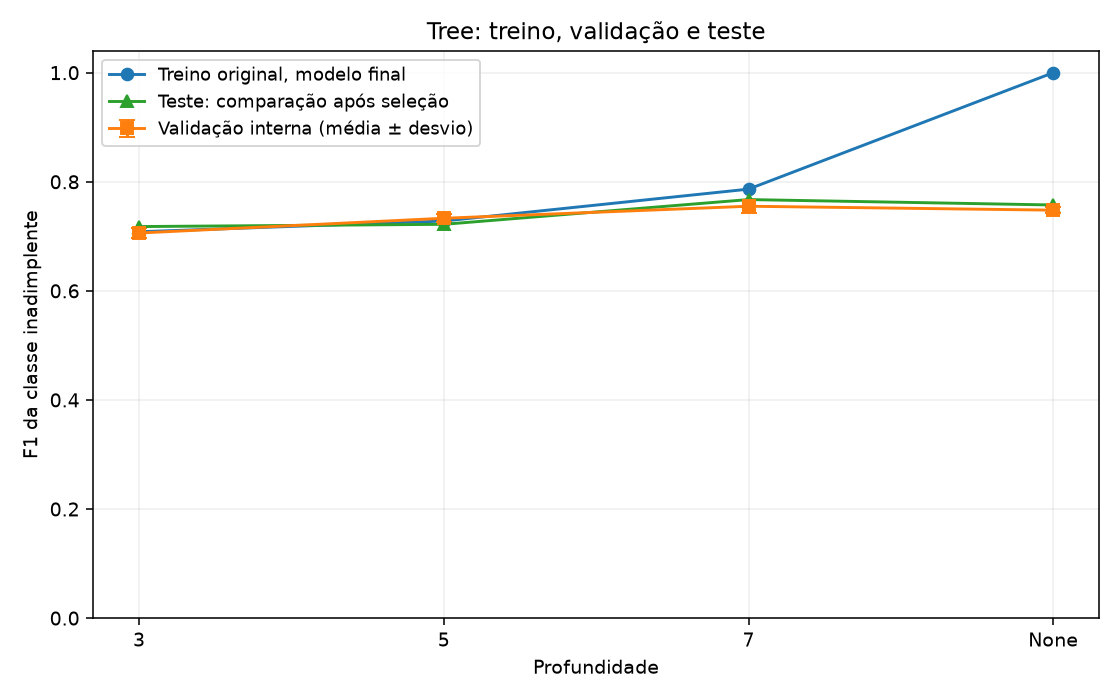

In [8]:
display(Markdown((ROOT / 'documentacao/experimentos_arvore.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/experimentos_corrigidos.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_overfitting_arvore.png')))


## 6. Avaliação e veredito de negócios

# Avaliação final e veredito

| model | param | test_accuracy | test_precision_1 | test_recall_1 | test_f1_1 | fp | fn |
| --- | --- | --- | --- | --- | --- | --- | --- |
| KNN | 9 | 0.7861 | 0.5075 | 0.7433 | 0.6031 | 1023 | 364 |
| Tree | 7 | 0.9028 | 0.8054 | 0.7327 | 0.7674 | 251 | 379 |

A classe positiva é inadimplência. FP é um bom pagador previsto como inadimplente;
FN é um inadimplente previsto como bom pagador. A previsão não é, por si só, uma
decisão efetiva de conceder ou recusar crédito.

## Comparação de erros

A árvore tem menor custo se custo_FN/custo_FP for menor que 51.467; no ponto há empate. Na relação oposta, o KNN tem menor custo.

A árvore trocou 772 falsos positivos a menos por 15 falsos negativos a mais em relação ao
KNN. Assim, a árvore é preferível enquanto um falso negativo custar menos de 51,467 vezes
um falso positivo. Se essa relação de custos for maior, o KNN passa a ter menor custo.

## Cenário de custos ilustrativos

Para demonstrar o cálculo, usamos custo_FP=R$ 1.000 e custo_FN=R$ 5.000.
Esses valores foram escolhidos para o exercício; não são estimativas apuradas,
não vieram da base e não são apresentados como parâmetros representativos de bancos.
Custo hipotético = FP × custo_FP + FN × custo_FN.

| model | param | fp | fn | custo_fp_hipotetico | custo_fn_hipotetico | custo_total_hipotetico |
| --- | --- | --- | --- | --- | --- | --- |
| KNN | 9 | 1023 | 364 | 1023000 | 1820000 | 2843000 |
| Tree | 7 | 251 | 379 | 251000 | 1895000 | 2146000 |

A diferença de R$ 697.000,00 vale apenas para essas contagens e essas hipóteses.
Não é economia realizada, receita prevista ou prova de redução efetiva da inadimplência.

## Recomendação

Recomendaria Árvore de Decisão, configuração 7, como candidato a um
piloto de apoio à análise neste cenário. Seu F1 de teste é 0.7674.
Os parâmetros de cada família foram selecionados somente por validação interna.
O custo real, a estabilidade temporal e a disponibilidade das variáveis no momento
da previsão precisam ser definidos antes de uso operacional.

## Importância das variáveis

| feature | importance |
| --- | --- |
| comprometimento_renda | 0.3170 |
| loan_int_rate | 0.2691 |
| person_income | 0.1449 |
| person_home_ownership_RENT | 0.0634 |
| loan_grade_D | 0.0524 |

Essas importâncias foram extraídas do MESMO objeto de árvore que produziu as predições
e a matriz deste relatório. Elas representam redução de impureza usada nos cortes,
não contribuição financeira, efeito causal ou percentual da decisão de um cliente.
A razão empréstimo/renda não representa parcela mensal.
Variáveis correlacionadas e a quantidade de cortes disponíveis podem afetar a importância.

## Limitações

O teste e a base completa já foram consultados durante o desenvolvimento anterior. A correção mantém a semente e a divisão e não usa o teste na seleção atual, mas não recupera a independência de um conjunto externo intocado.

Não há datas para demonstrar validação temporal. Taxa de juros e classificação do empréstimo
podem depender da análise de crédito: a base não esclarece em que momento estão disponíveis.
O estudo não demonstra causalidade nem adequação para decisões automatizadas reais.


,model,param,prefix,cv_f1,test_accuracy,test_precision_1,test_recall_1,test_f1_1,fp,fn,tn,tp
0,KNN,9,knn_k9,0.598411,0.786056,0.507463,0.743300,0.603147,1023,364,4042,1054
1,Tree,7,arvore_depth7,0.755135,0.902823,0.805426,0.732722,0.767356,251,379,4814,1039


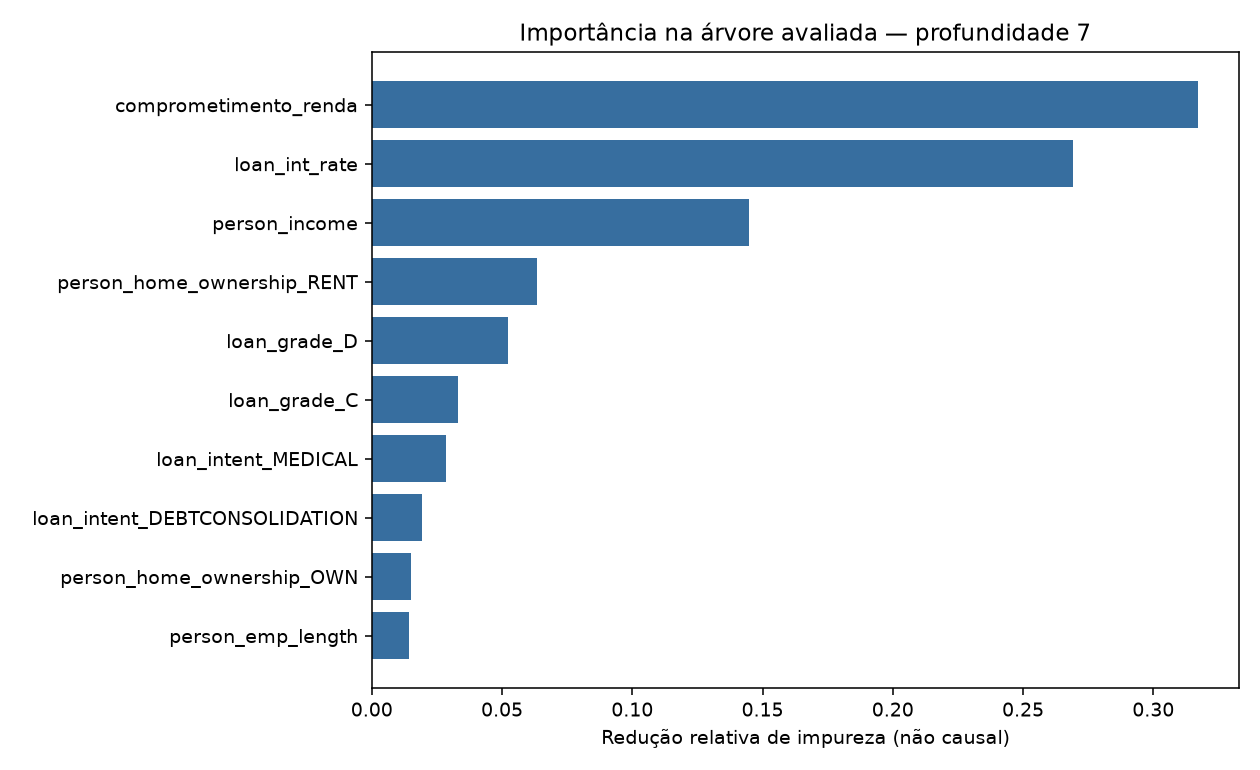

In [9]:
display(Markdown((ROOT / 'documentacao/avaliacao_final.md').read_text()))
display(pd.read_csv(ROOT / 'resultados/avaliacao_corrigida.csv'))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/feature_importance_arvore.png')))


## KNN e integridade
O teste foi consultado em versões anteriores: a execução atual evita seu uso na seleção, mas não transforma essa amostra em teste externo intocado. Custos são hipóteses didáticas.

# Experimentos: KNN

Este documento foi regenerado pelo pipeline vigente. Resultados anteriores permanecem no histórico Git e não devem ser usados na análise.

| param | train_f1_1_mean | cv_f1 | cv_std | treino_f1_1 | teste_f1_1 | gap_f1 |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 0.8444 | 0.5925 | 0.0107 | 0.8458 | 0.6018 | 0.2440 |
| 5 | 0.7586 | 0.5832 | 0.0076 | 0.7612 | 0.5931 | 0.1680 |
| 7 | 0.7197 | 0.5898 | 0.0031 | 0.7245 | 0.5985 | 0.1259 |
| 9 | 0.7048 | 0.5984 | 0.0040 | 0.7083 | 0.6031 | 0.1051 |

train_f1_1_mean mede o treino original de cada dobra; cv_f1 mede sua validação.
treino_f1_1 é medido no treino original completo, sem repetições do oversampling.
As métricas de teste de todas as configurações atendem à comparação pedida pelo problema,
mas são calculadas somente depois de persistir os parâmetros selecionados.

A seleção foi 9, com F1 médio de validação 0.5984.
Usamos o maior F1 médio; em empate exato, K maior no KNN e menor profundidade na árvore.

O intervalo observado do gap treino-validação é 0.1064 a
0.2519. Quanto maior a vantagem no treino, maior o indício de ajuste excessivo;
não aplicamos um limite arbitrário para eliminar modelos. Médias próximas com desempenho
baixo podem indicar subajuste, sem provar isso isoladamente. A pequena diferença entre
candidatos precisa ser lida junto com os desvios das dobras, não como superioridade universal.

## Leitura do overfitting

No KNN, K=3 teve F1 médio de treino 0.8444 e F1 de validação 0.5925, um gap de 0.2519. Com K=9, o F1 de treino caiu para 0.7048, mas o F1 de validação subiu para 0.5984 e o gap caiu para 0.1064. Por isso K=9 foi escolhido: ele generalizou melhor entre os quatro valores testados, apesar de a diferença de validação ser pequena.

O gráfico de treino, validação e teste está em resultados/avaliacao_final/.


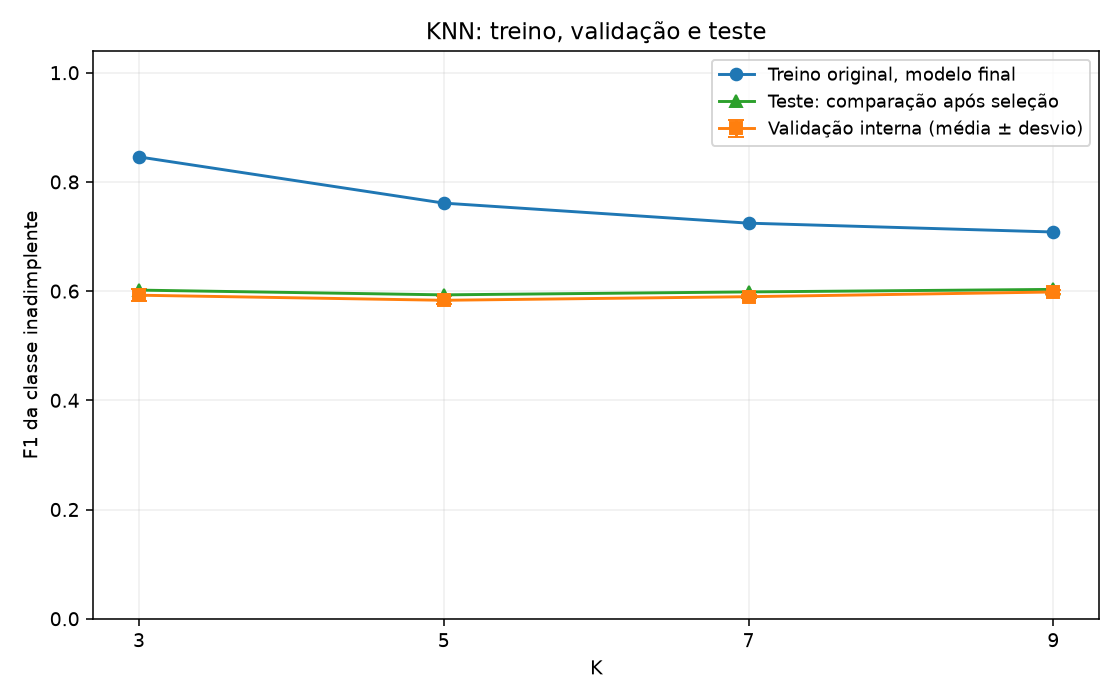

Integridade dos CSVs originais confirmada.


In [10]:
display(Markdown((ROOT / 'documentacao/experimentos_knn.md').read_text()))
display(Image(filename=str(ROOT / 'resultados/avaliacao_final/curva_validacao_knn.png')))
from pipeline_credito import verify_originals
verify_originals()
print('Integridade dos CSVs originais confirmada.')


                  precision    recall  f1-score   support

      Em dia (0)     0.9174    0.7980    0.8536      5065
Inadimplente (1)     0.5075    0.7433    0.6031      1418

        accuracy                         0.7861      6483
       macro avg     0.7124    0.7707    0.7284      6483
    weighted avg     0.8277    0.7861    0.7988      6483



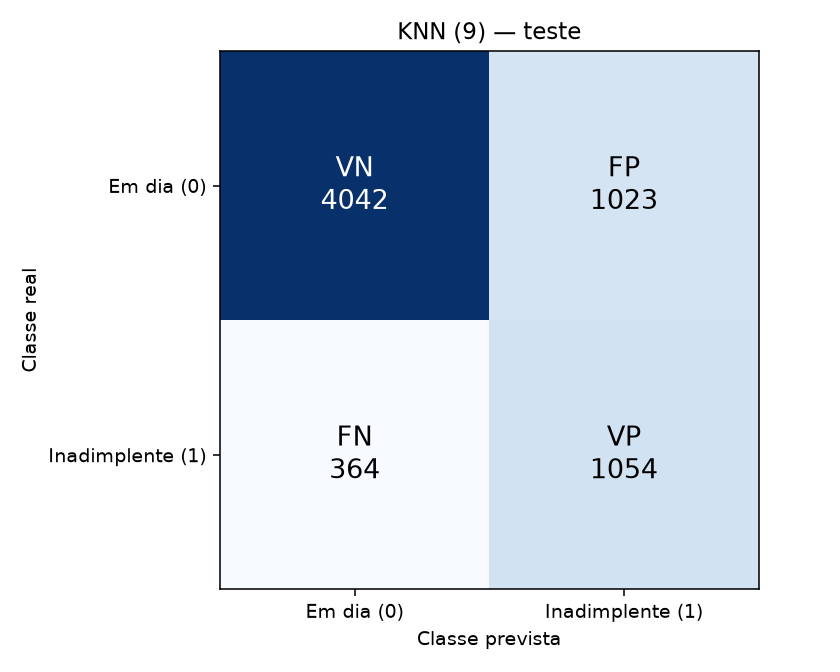

                  precision    recall  f1-score   support

      Em dia (0)     0.9270    0.9504    0.9386      5065
Inadimplente (1)     0.8054    0.7327    0.7674      1418

        accuracy                         0.9028      6483
       macro avg     0.8662    0.8416    0.8530      6483
    weighted avg     0.9004    0.9028    0.9011      6483



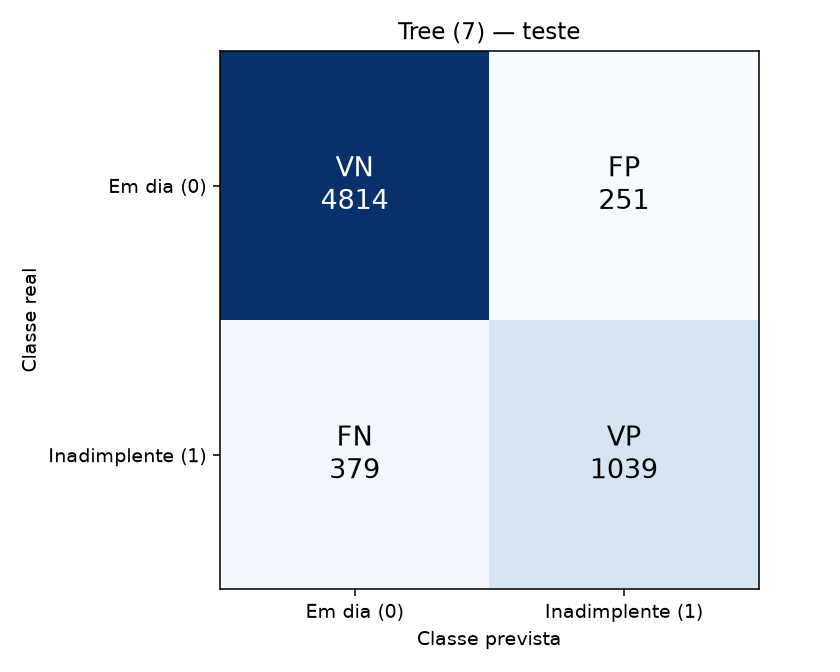

In [11]:
import json
selected = json.loads((ROOT / 'resultados/parametros_selecionados.json').read_text())['selecionados']
for model, param in selected.items():
    prefix = f'knn_k{param}' if model == 'KNN' else f'arvore_depth{param}'
    folder = ROOT / 'resultados/avaliacao_final'
    print((folder / f'{prefix}_classification_report.txt').read_text())
    display(Image(filename=str(folder / f'{prefix}_matriz_confusao.png')))
